# 03 — GLOF Homogeneity Tests

Tests whether the annual maxima observed during the GLOF period (2011–2020) are statistically
consistent with the pre-GLOF reference distribution (1944–2010).

Two test families:
- **Distribution-based (KS):** Apply the reference GEV as null, test 2011–2020 peaks via the
  probability integral transform (Module 1, §1.3.1, §3.1.2).
- **Non-parametric (Rank-Sum):** Compare GLOF-year and non-GLOF-year annual maxima as two
  independent groups, without assuming a distributional form (Module 1, §2.4.1; professor's suggestion).

| # | Method | Lecture Reference |
|---|--------|------------------|
| 1 | Data loading + series construction | — |
| 2 | Probability integral transform | Module 1, §1.3.1 |
| 3 | KS test: Group A (GLOF-inclusive) | Module 1, §3.1.2, Eq. 3.3 |
| 4 | KS test: Group B (GLOF-masked) | Module 1, §3.1.2, Eq. 3.3 |
| 5 | Rank-Sum Test (independent groups) | Module 1, §2.4.1 |
| 6 | Probability plot (Q-Q style) | Module 1, §3.2 |
| 7 | 2011–2020 peaks vs. reference GEV return-period plot | — |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from pathlib import Path

from utils import (
    load_grdc_discharge, extract_annual_maxima, mask_glof_windows,
    gringorten, fit_gev, probability_integral_transform,
    ks_test_vs_uniform, ks_critical_value, rank_sum_test, GLOF_DATES,
)

FIGS = Path('../figures/03_tests')
FIGS.mkdir(exist_ok=True)

T_plot = np.logspace(np.log10(1.01), np.log10(500), 300)

## 1 — Load Data & Construct Test Groups

In [2]:
Q_daily  = load_grdc_discharge()
Q_masked = mask_glof_windows(Q_daily)

Q_full  = extract_annual_maxima(Q_daily)
Q_clean = extract_annual_maxima(Q_masked)
Q_ref   = Q_full[Q_full.index <= 2010]

# Fit reference GEV on homogeneous 1944-2010 period
xi_r, mu_r, sigma_r, q_r, lo_r, hi_r = fit_gev(Q_ref.values, T_plot)
print(f'Reference GEV (1944–2010):  n={len(Q_ref)}')
print(f'  mu={mu_r:.4f},  sigma={sigma_r:.4f},  xi={xi_r:.4f}')

# Test period: 2011-2020 (8 years with GLOF activity)
test_years = list(range(2011, 2021))
group_A = Q_full.reindex(test_years).dropna()   # GLOF-inclusive
group_B = Q_clean.reindex(test_years).dropna()  # GLOF-masked
print(f'\nTest group A (GLOF-inclusive): n={len(group_A)}')
print(f'Test group B (GLOF-masked):    n={len(group_B)}')

Reference GEV (1944–2010):  n=67
  mu=10.0376,  sigma=1.5424,  xi=0.1009

Test group A (GLOF-inclusive): n=10
Test group B (GLOF-masked):    n=10


## 2 — Probability Integral Transform (Module 1, §1.3.1)

Under H₀ (no shift), u_i = F_ref(x_i) ~ Uniform(0, 1).
Values near 1 indicate observations in the extreme upper tail of the reference.

In [3]:
u_A = probability_integral_transform(group_A.values, xi_r, mu_r, sigma_r)
u_B = probability_integral_transform(group_B.values, xi_r, mu_r, sigma_r)

print(f'{"Year":>5}  {"Q_A":>7}  {"u_A":>7}  {"T_A (yr)":>10}  |  {"Q_B":>7}  {"u_B":>7}  {"T_B (yr)":>10}')
print('-' * 65)
for yr in test_years:
    qa = group_A.get(yr, float('nan'))
    qb = group_B.get(yr, float('nan'))
    ua = probability_integral_transform(np.array([qa]), xi_r, mu_r, sigma_r)[0] if not np.isnan(qa) else float('nan')
    ub = probability_integral_transform(np.array([qb]), xi_r, mu_r, sigma_r)[0] if not np.isnan(qb) else float('nan')
    Ta = 1 / (1 - ua) if not np.isnan(ua) else float('nan')
    Tb = 1 / (1 - ub) if not np.isnan(ub) else float('nan')
    print(f'{yr:>5}  {qa:>7.2f}  {ua:>7.4f}  {Ta:>10.1f}  |  {qb:>7.2f}  {ub:>7.4f}  {Tb:>10.1f}')

 Year      Q_A      u_A    T_A (yr)  |      Q_B      u_B    T_B (yr)
-----------------------------------------------------------------
 2011    15.08   0.9424        17.4  |    15.08   0.9424        17.4
 2012    14.56   0.9264        13.6  |    14.56   0.9264        13.6
 2013    14.99   0.9398        16.6  |    11.10   0.5986         2.5
 2014    21.09   0.9955       220.0  |    14.24   0.9140        11.6
 2015    10.11   0.3839         1.6  |     9.11   0.1565         1.2
 2016    13.97   0.9015        10.2  |    13.97   0.9015        10.2
 2017    13.94   0.9005        10.0  |    10.66   0.5104         2.0
 2018    19.24   0.9907       107.1  |     9.81   0.3127         1.5
 2019    10.80   0.5398         2.2  |    10.80   0.5398         2.2
 2020     9.88   0.3314         1.5  |     9.88   0.3314         1.5


## 3 — KS Test: Group A — GLOF-Inclusive Peaks (Module 1, §3.1.2)

H₀: 2011–2020 full annual maxima are consistent with the reference GEV (1944–2010).
Reference parameters come from an independent sample, so no Lilliefors correction needed.

Critical value: C_α = K_α / (√n + 0.12 + 0.11/√n), K₀.₀₅ = 1.358 (Module 1, Eq. 3.3).

In [4]:
ks_d_A, ks_p_A = ks_test_vs_uniform(u_A)
c_A = ks_critical_value(len(u_A), alpha=0.05)
print('KS test — Group A (GLOF-inclusive):')
print(f'  n={len(u_A)},  D = {ks_d_A:.4f},  C_0.05 = {c_A:.4f},  p = {ks_p_A:.4f}')
if ks_d_A > c_A:
    print('  D > C_0.05 -> REJECT H₀ at 5%: GLOF-inclusive peaks are NOT consistent with the pre-GLOF reference GEV.')
else:
    print(f'  D ≤ C_0.05 -> Cannot reject H₀ at 5% (p={ks_p_A:.3f}).')

KS test — Group A (GLOF-inclusive):
  n=10,  D = 0.6005,  C_0.05 = 0.4094,  p = 0.0006
  D > C_0.05 -> REJECT H₀ at 5%: GLOF-inclusive peaks are NOT consistent with the pre-GLOF reference GEV.


## 4 — KS Test: Group B — GLOF-Masked Peaks (Module 1, §3.1.2)

H₀: GLOF-masked 2011–2020 maxima are consistent with the reference GEV.
If masking correctly removes the GLOF signal, Group B should fail to reject H₀.

In [5]:
ks_d_B, ks_p_B = ks_test_vs_uniform(u_B)
c_B = ks_critical_value(len(u_B), alpha=0.05)
print('KS test — Group B (GLOF-masked):')
print(f'  n={len(u_B)},  D = {ks_d_B:.4f},  C_0.05 = {c_B:.4f},  p = {ks_p_B:.4f}')
if ks_d_B > c_B:
    print('  D > C_0.05 -> REJECT H₀ at 5%: even after masking, peaks differ from the reference.')
else:
    print(f'  D ≤ C_0.05 -> Cannot reject H₀ at 5% (p={ks_p_B:.3f}).')
    print('     GLOF-masked peaks are consistent with the pre-GLOF reference GEV.')

print('\nSummary:')
print(f'  Group A (full):    D={ks_d_A:.4f},  C={c_A:.4f},  p={ks_p_A:.4f}')
print(f'  Group B (masked):  D={ks_d_B:.4f},  C={c_B:.4f},  p={ks_p_B:.4f}')

KS test — Group B (GLOF-masked):
  n=10,  D = 0.3015,  C_0.05 = 0.4094,  p = 0.2652
  D ≤ C_0.05 -> Cannot reject H₀ at 5% (p=0.265).
     GLOF-masked peaks are consistent with the pre-GLOF reference GEV.

Summary:
  Group A (full):    D=0.6005,  C=0.4094,  p=0.0006
  Group B (masked):  D=0.3015,  C=0.4094,  p=0.2652


## 5 — Rank-Sum Test: GLOF vs. Non-GLOF Years (Module 1, §2.4.1)

Non-parametric test for two independent groups — no distributional assumption required.
Also known as the Wilcoxon rank-sum test or Mann-Whitney U test (same procedure, per lecture §2.4.1).
H₀: P[X > Y] = 0.5, i.e. annual maxima in GLOF years and non-GLOF years come from the same population.

Three comparisons:
- **5a:** GLOF-year full maxima vs. non-GLOF-year maxima (tests GLOF inflation directly)
- **5b:** GLOF-year masked maxima vs. non-GLOF-year maxima (tests whether masking restores homogeneity)
- **5c:** Pre-GLOF (1944–2010) vs. post-GLOF masked (2011–2020) as additional era check

In [6]:
glof_years_set = set(GLOF_DATES.keys())
Q_non_glof = Q_full[~Q_full.index.isin(glof_years_set)]

# 5a: GLOF-year full peaks vs. non-GLOF years
Q_glof_full = Q_full[Q_full.index.isin(glof_years_set)]
U_5a, p_5a = rank_sum_test(Q_glof_full.values, Q_non_glof.values)

# 5b: GLOF-year masked peaks vs. non-GLOF years
Q_glof_masked = Q_clean[Q_clean.index.isin(glof_years_set)]
U_5b, p_5b = rank_sum_test(Q_glof_masked.values, Q_non_glof.values)

# 5c: pre-GLOF era vs. post-GLOF masked era
Q_post_masked = Q_clean[Q_clean.index >= 2011]
U_5c, p_5c = rank_sum_test(Q_ref.values, Q_post_masked.values)

print('Rank-Sum Test results (Module 1, §2.4.1) — H₀: same population, two-sided:')
print(f'  5a  GLOF-year full vs. non-GLOF:       W={U_5a:.1f},  p={p_5a:.4f}  {"-> REJECT" if p_5a<0.05 else "-> cannot reject"} H₀')
print(f'  5b  GLOF-year masked vs. non-GLOF:     W={U_5b:.1f},  p={p_5b:.4f}  {"-> REJECT" if p_5b<0.05 else "-> cannot reject"} H₀')
print(f'  5c  Pre-GLOF era vs. post-GLOF masked: W={U_5c:.1f},  p={p_5c:.4f}  {"-> REJECT" if p_5c<0.05 else "-> cannot reject"} H₀')

print()
print('Interpretation:')
print('  5a: Is GLOF-year full series different from the rest? (expects rejection)')
print('  5b: Does masking restore homogeneity? (expects non-rejection)')
print('  5c: Is the post-GLOF non-GLOF hydrology the same as pre-GLOF? (secular change check)')

Rank-Sum Test results (Module 1, §2.4.1) — H₀: same population, two-sided:
  5a  GLOF-year full vs. non-GLOF:       W=428.0,  p=0.0012  -> REJECT H₀
  5b  GLOF-year masked vs. non-GLOF:     W=305.0,  p=0.2917  -> cannot reject H₀
  5c  Pre-GLOF era vs. post-GLOF masked: W=257.0,  p=0.2402  -> cannot reject H₀

Interpretation:
  5a: Is GLOF-year full series different from the rest? (expects rejection)
  5b: Does masking restore homogeneity? (expects non-rejection)
  5c: Is the post-GLOF non-GLOF hydrology the same as pre-GLOF? (secular change check)


## 6 — Probability Plot: Groups A & B vs. Reference GEV (Module 1, §3.2)

Probability plot (Q-Q style, Module 1, §3.2): plot observed x_i against the theoretical quantile
F_ref^{-1}(q_i), where q_i are Gringorten plotting positions.
Points on the 1:1 diagonal → observations consistent with the reference GEV.
Points above the diagonal → observed peaks are higher than the reference predicts (GLOF inflation).

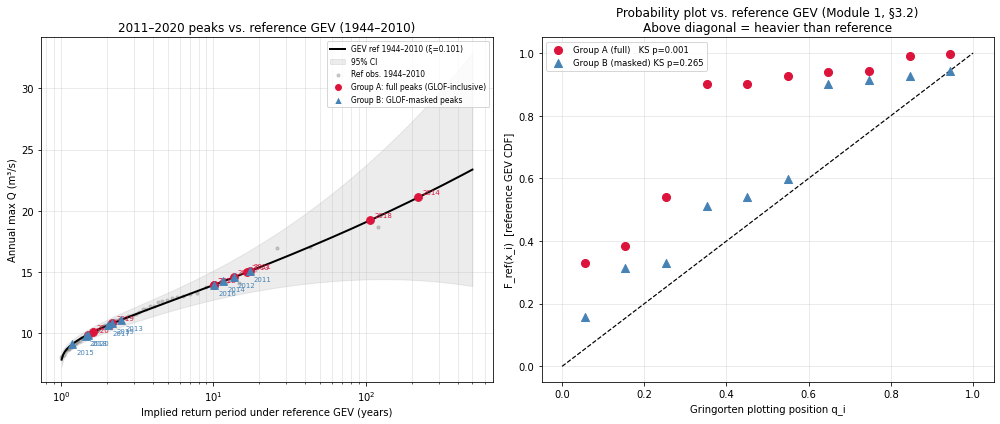

In [7]:
from scipy.stats import genextreme

def gev_ppf(u, xi, mu, sigma):
    """GEV quantile function (inverse CDF) for plotting positions u."""
    return genextreme.ppf(u, c=-xi, loc=mu, scale=sigma)

# Gringorten positions for reference observations (for the left panel)
Qr_s, Tr_e = gringorten(Q_ref.values)
T_A = 1 / (1 - u_A)
T_B = 1 / (1 - u_B)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left panel: 2011-2020 peaks on reference GEV return-period plot ───────────
ax = axes[0]
ax.semilogx(T_plot, q_r, 'k-', lw=2, label=f'GEV ref 1944–2010 (ξ={xi_r:.3f})')
ax.fill_between(T_plot, lo_r, hi_r, color='gray', alpha=0.15, label='95% CI')
ax.scatter(Tr_e, Qr_s, s=10, color='gray', alpha=0.35, label='Ref obs. 1944–2010')

for yr, q, Ti in zip(group_A.index, group_A.values, T_A):
    ax.scatter(Ti, q, color='crimson', marker='o', zorder=6, s=60)
    ax.annotate(str(yr), (Ti, q), xytext=(4, 3),
                textcoords='offset points', fontsize=7, color='crimson')
for yr, q, Ti in zip(group_B.index, group_B.values, T_B):
    ax.scatter(Ti, q, color='steelblue', marker='^', zorder=6, s=60)
    ax.annotate(str(yr), (Ti, q), xytext=(4, -10),
                textcoords='offset points', fontsize=7, color='steelblue')

legend_extra = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson',
           ms=8, label='Group A: full peaks (GLOF-inclusive)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='steelblue',
           ms=8, label='Group B: GLOF-masked peaks'),
]
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_extra, fontsize=7.5)
ax.set_xlabel('Implied return period under reference GEV (years)')
ax.set_ylabel('Annual max Q (m³/s)')
ax.set_title('2011–2020 peaks vs. reference GEV (1944–2010)')
ax.grid(True, which='both', alpha=0.3)

# ── Right panel: Probability plot Q-Q style (Module 1, §3.2) ──────────────────
ax2 = axes[1]
ax2.plot([0, 1], [0, 1], 'k--', lw=1.2)  # 1:1 reference line

for arr, color, marker, label in [
    (group_A.values, 'crimson',   'o', f'Group A (full)   KS p={ks_p_A:.3f}'),
    (group_B.values, 'steelblue', '^', f'Group B (masked) KS p={ks_p_B:.3f}'),
]:
    n_pts = len(arr)
    arr_s = np.sort(arr)
    # Gringorten plotting positions
    q_i = (np.arange(1, n_pts + 1) - 0.44) / (n_pts + 0.12)
    # Theoretical quantiles under reference GEV
    x_theo = gev_ppf(q_i, xi_r, mu_r, sigma_r)
    # Normalize both axes to [0,1] range of reference GEV for visual comparison
    # Use the CDF scale (probability scale) — plot F_ref(x_obs) vs q_i
    ax2.scatter(q_i, genextreme.cdf(arr_s, c=-xi_r, loc=mu_r, scale=sigma_r),
                color=color, marker=marker, s=65, zorder=5, label=label)

ax2.set_xlabel('Gringorten plotting position q_i')
ax2.set_ylabel('F_ref(x_i)  [reference GEV CDF]')
ax2.set_title('Probability plot vs. reference GEV (Module 1, §3.2)\nAbove diagonal = heavier than reference')
ax2.legend(fontsize=8.5)
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIGS / '03_reference_gev_test.png', dpi=150)
plt.show()

## 7 — Summary of All Tests

In [8]:
print('=' * 65)
print('TEST SUMMARY')
print('=' * 65)
print()
print('Kolmogorov-Smirnov (Module 1, §3.1.2) — D_n vs. C_α = K_α/(√n + 0.12 + 0.11/√n):')
print(f'  Group A full vs. ref GEV:    D={ks_d_A:.4f},  C={c_A:.4f}  -> {"REJECT" if ks_d_A>c_A else "fail to reject"} H₀')
print(f'  Group B masked vs. ref GEV:  D={ks_d_B:.4f},  C={c_B:.4f}  -> {"REJECT" if ks_d_B>c_B else "fail to reject"} H₀')
print()
print('Rank-Sum Test (Module 1, §2.4.1) — non-parametric, independent groups:')
print(f'  GLOF-year full vs. non-GLOF:       W={U_5a:.1f},  p={p_5a:.4f}  -> {"REJECT" if p_5a<0.05 else "fail to reject"} H₀')
print(f'  GLOF-year masked vs. non-GLOF:     W={U_5b:.1f},  p={p_5b:.4f}  -> {"REJECT" if p_5b<0.05 else "fail to reject"} H₀')
print(f'  Pre-GLOF era vs. post-GLOF masked: W={U_5c:.1f},  p={p_5c:.4f}  -> {"REJECT" if p_5c<0.05 else "fail to reject"} H₀')
print()
print('Conclusion:')
if (ks_d_A > c_A) and not (ks_d_B > c_B):
    print('  Both test families are consistent: the distributional shift in 2011–2020')
    print('  is attributable to GLOFs, not to secular hydroclimatic change.')
else:
    print('  Results require interpretation — see individual test outputs above.')

TEST SUMMARY

Kolmogorov-Smirnov (Module 1, §3.1.2) — D_n vs. C_α = K_α/(√n + 0.12 + 0.11/√n):
  Group A full vs. ref GEV:    D=0.6005,  C=0.4094  -> REJECT H₀
  Group B masked vs. ref GEV:  D=0.3015,  C=0.4094  -> fail to reject H₀

Rank-Sum Test (Module 1, §2.4.1) — non-parametric, independent groups:
  GLOF-year full vs. non-GLOF:       W=428.0,  p=0.0012  -> REJECT H₀
  GLOF-year masked vs. non-GLOF:     W=305.0,  p=0.2917  -> fail to reject H₀
  Pre-GLOF era vs. post-GLOF masked: W=257.0,  p=0.2402  -> fail to reject H₀

Conclusion:
  Both test families are consistent: the distributional shift in 2011–2020
  is attributable to GLOFs, not to secular hydroclimatic change.
